# `E_macro` — Key Findings Across Six Pillars

**Decision on the table:** which pillars earn their place in the fused embedding,
which get changed, and which get cut.

Every number below is recomputed from `data/*.parquet` or read from the
per-source `stats.json` bundles written by the analysis scripts.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd().parent if Path.cwd().name == "analysis-output" else Path.cwd()
DATA = REPO / "data"
ANALYSIS = REPO / "analysis-output"

mpl.rcParams.update({
    "figure.figsize": (11, 5.5),
    "figure.dpi": 110,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

INK = "#1f2a37"
ACCENT = "#c2410c"
MUTED = "#9ca3af"
GOOD = "#15803d"

In [2]:
# --- load all six pillars -------------------------------------------------
src = {
    # Source A now ships text features; the legacy embeddings parquet is
    # retained for Source A's own EDA but is no longer regenerated (see S2).
    "A": pd.read_parquet(DATA / "source_a_text_features.parquet"),
    "B": pd.read_parquet(DATA / "source_b_qcew.parquet"),
    "C": pd.read_parquet(DATA / "source_c_fred.parquet"),
    "D": pd.read_parquet(DATA / "source_d_faf.parquet"),
    "E": pd.read_parquet(DATA / "source_e_irs_soi.parquet"),
    "F": pd.read_parquet(DATA / "source_f_usda_typology.parquet"),
}

STATS_FILES = {
    "A": "source-a/stats.json",
    "B": "source-b/source_b_stats.json",
    "C": "source-c/source_c_stats.json",
    "D": "source-d/source_d_stats.json",
    "E": "source-e/source_e_stats.json",
    "F": "source-f/source_f_stats.json",
}
stats = {k: json.loads((ANALYSIS / v).read_text()) for k, v in STATS_FILES.items()}

for k, df in src.items():
    print(f"Source {k}: {len(df):>5,} counties x {df.shape[1]:>2} cols")

Source A: 3,144 counties x 35 cols
Source B: 3,143 counties x 42 cols
Source C: 3,144 counties x  9 cols
Source D: 3,144 counties x 16 cols
Source E: 3,143 counties x  9 cols
Source F: 3,144 counties x 21 cols


In [3]:
# --- one joined frame on fips_code ---------------------------------------
# `gdp_velocity_pct` is now a column in the parquet rather than something
# every consumer recomputes locally -- that fix is Section 4a.
c = src["C"]

panel = (
    src["F"][["fips_code", "county_name", "metro_2023",
              "low_postsecondary_ed", "low_employment", "population_loss",
              "housing_stress", "retirement_destination", "persistent_poverty"]]
    .merge(c[["fips_code", "unemployment_velocity", "gdp_velocity",
              "gdp_velocity_pct", "gdp_latest"]], on="fips_code", how="left")
    .merge(src["D"][["fips_code", "total_outbound_tons", "total_inbound_tons",
                     "out_partner_hhi"]], on="fips_code", how="left")
    .merge(src["E"][["fips_code", "capital_to_wage_ratio", "num_returns"]],
           on="fips_code", how="left")
)

DISTRESS_FLAGS = ["low_postsecondary_ed", "low_employment", "population_loss",
                  "housing_stress", "retirement_destination", "persistent_poverty"]
panel["distress_count"] = panel[DISTRESS_FLAGS].astype("float").sum(axis=1)
panel["total_tons"] = panel["total_outbound_tons"] + panel["total_inbound_tons"]
panel["log_tons"] = np.log10(panel["total_tons"].clip(lower=1))

print(f"panel: {len(panel):,} counties x {panel.shape[1]} cols")
print(f"complete velocity rows: {panel['gdp_velocity_pct'].notna().sum():,}")

panel: 3,144 counties x 21 cols
complete velocity rows: 3,080


---

## 1. Verdict scorecard

One row per pillar. **Evidence** is the single number that decided it, unpacked
in its own section below. **Decision** says what actually happens to that pillar,
in words rather than shorthand. **Status** says whether it has landed:

- **APPLIED** — already changed in the ingestion code and the parquet files, and
  reflected in every number in this notebook.
- **PENDING — fusion** — a decision about how the fusion step should read the
  pillar. Nothing to change in the data; the fusion step does not exist yet.
- **NO CHANGE** — the pillar stays exactly as it is; what changes is how much
  weight to put on it.

Section 1b, directly after the table, lists where each source is missing data
and why.

In [4]:
from scipy.stats import pearsonr

OUTPUTS = REPO / "outputs"

# Full 15-pair pillar crossvalidation sweep, including the county-size-controlled
# partial correlations (scripts/analyze_pillar_pair_crossvalidation.py).
sweep = pd.read_csv(OUTPUTS / "pillar_pair_crossvalidation.csv")


# Returns (raw r, size-controlled r) for one feature pair in the sweep.
def sweep_r(feature_x: str, feature_y: str) -> tuple[float, float]:
    row = sweep.query("feature_x == @feature_x and feature_y == @feature_y").iloc[0]
    return float(row["r"]), float(row["r_size_controlled"])


F_x_A_R, F_x_A_PARTIAL = sweep_r("content_length", "metro_2023")
F_x_D_R, F_x_D_PARTIAL = sweep_r("log_total_tons", "distress_count")
B_x_E_R, B_x_E_PARTIAL = sweep_r("lq_emp_53", "capital_to_wage_ratio")

# Permutation p-values (499 perms) from the cross-source reports; the Mantel
# test against economic distance is too costly to rerun live.
F_x_D_P = F_x_A_P = 0.0020
A_GEO_R = stats["A"]["mantel_r"]      # embedding similarity vs geography
A_ECON_R = -0.0406                    # embedding similarity vs economic distance
B_BEST_SECTOR_R = 0.206               # Real Estate & Rental & Leasing LQ vs GDP velocity

# Section 2b's head-to-head, quoted in the scorecard's Source A row.
_rep = json.loads((ANALYSIS / "source-a" / "source_a_representation_stats.json").read_text())
A_WINS, A_TARGETS = _rep["n_embedding_wins"], _rep["n_targets"]
A_EMBED_LIFT, A_LENGTH_LIFT = _rep["mean_lift_best_embedding"], _rep["mean_lift_length"]

# Section 8's leave-one-pillar-out result for Source D, quoted in the scorecard.
_signal = pd.read_csv(OUTPUTS / "pillar_matrix_signal.csv")
_d_tons = _signal.query("column == 'log_total_tons'").iloc[0]
D_BASELINE_R2 = float(_d_tons["r2_baseline"])
D_LIFT = float(_d_tons["lift"])

# Each row: what the pillar is for, the number that decided it, what happens to
# it, and whether that has landed yet. "Applied" means it is in the parquet and
# in every number below; "Pending" means it is a fusion-step decision and the
# fusion step does not exist yet.
scorecard = pd.DataFrame([
    dict(
        Pillar="A — Wikipedia embeddings",
        Measures="Narrative / identity",
        Evidence=f"beats `content_length` on {A_WINS} of {A_TARGETS} cross-pillar targets, "
                 f"but by {A_EMBED_LIFT:+.4f} R² against {A_LENGTH_LIFT:+.4f} — real signal, "
                 "negligible size, 2.2GB model (Section 2b)",
        Decision="Drop the 1024-number embedding, keep the source. Wikipedia text "
                 "stays in, represented by cheap features like article length.",
        Status="APPLIED",
    ),
    dict(
        Pillar="B — QCEW location quotients",
        Measures="Industrial core",
        Evidence=f"magnitude r = {stats['B']['dominant_lq_vs_gdp_velocity_pct_corr']:.3f}, "
                 f"but best single sector r = {B_BEST_SECTOR_R:.3f}",
        Decision="Keep the pillar, read a different feature: all 20 industry columns "
                 "instead of the single 'how specialized is this county' number.",
        Status="PENDING — fusion",
    ),
    dict(
        Pillar="C — FRED velocity",
        Measures="Economic momentum",
        Evidence=f"its own two velocities correlate r = {stats['C']['velocity_correlation']:.3f}; "
                 f"{stats['C']['quadrant_counts']['Growing but Loosening'] / stats['C']['quadrant_n_counties']:.1%} "
                 "of counties in one quadrant",
        Decision="Keep the pillar, fix the metric: GDP velocity as a percentage, not "
                 "dollars. The four-quadrant label is retired as a predictor.",
        Status="APPLIED",
    ),
    dict(
        Pillar="D — FAF freight tonnage",
        Measures="Trade gravity",
        Evidence="monotone across tonnage quartiles, but county size and state "
                 f"alone predict log tonnage at R² = {D_BASELINE_R2:.3f} and the other "
                 f"five pillars add {D_LIFT:+.3f} (Section 8)",
        Decision="Keep the pillar as is, but read it as a size-and-connectedness "
                 "measure. Most of what it says, county size already said.",
        Status="NO CHANGE",
    ),
    dict(
        Pillar="E — IRS capital ratio",
        Measures="Capital composition",
        Evidence=f"r = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_corr']:.3f} "
                 f"(p = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_p']:.3f}); "
                 "monotone quartiles, but low-return counties are one-time-sale noise",
        Decision="Keep the pillar, mark the unreliable tail: counties with few tax "
                 "returns, where the ratio reflects one-off land sales.",
        Status="APPLIED",
    ),
    dict(
        Pillar="F — USDA typology",
        Measures="Structural resilience",
        Evidence=f"distress vs velocity p = {stats['F']['distress_vs_unemployment_velocity_p']:.2f} (null); "
                 f"distress vs freight r = {F_x_D_R:.3f} but only {F_x_D_PARTIAL:.3f} once "
                 "county size is controlled",
        Decision="Keep the pillar, ask it a different question: use it to describe and "
                 "group counties, not to predict which ones are speeding up.",
        Status="PENDING — fusion",
    ),
])

STATUS_STYLE = {
    "APPLIED": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "PENDING — fusion": "background-color: #fef3c7; color: #92400e; font-weight: 700",
    "NO CHANGE": "background-color: #f3f4f6; color: #374151; font-weight: 700",
}

(scorecard.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top",
                       "font-size": "13px", "padding": "10px"})
    .set_properties(subset=["Pillar"], **{"font-weight": "700"})
    .map(lambda v: STATUS_STYLE.get(v, ""), subset=["Status"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "10px")]},
        {"selector": "", "props": [("border-collapse", "collapse")]},
    ])
    .set_caption("E_macro pillar scorecard — what happens to each source, and whether it has landed"))

Pillar,Measures,Evidence,Decision,Status
A — Wikipedia embeddings,Narrative / identity,"beats `content_length` on 21 of 28 cross-pillar targets, but by +0.0030 R² against +0.0012 — real signal, negligible size, 2.2GB model (Section 2b)","Drop the 1024-number embedding, keep the source. Wikipedia text stays in, represented by cheap features like article length.",APPLIED
B — QCEW location quotients,Industrial core,"magnitude r = 0.046, but best single sector r = 0.206","Keep the pillar, read a different feature: all 20 industry columns instead of the single 'how specialized is this county' number.",PENDING — fusion
C — FRED velocity,Economic momentum,its own two velocities correlate r = 0.009; 63.8% of counties in one quadrant,"Keep the pillar, fix the metric: GDP velocity as a percentage, not dollars. The four-quadrant label is retired as a predictor.",APPLIED
D — FAF freight tonnage,Trade gravity,"monotone across tonnage quartiles, but county size and state alone predict log tonnage at R² = 0.887 and the other five pillars add +0.005 (Section 8)","Keep the pillar as is, but read it as a size-and-connectedness measure. Most of what it says, county size already said.",NO CHANGE
E — IRS capital ratio,Capital composition,"r = 0.071 (p = 0.002); monotone quartiles, but low-return counties are one-time-sale noise","Keep the pillar, mark the unreliable tail: counties with few tax returns, where the ratio reflects one-off land sales.",APPLIED
F — USDA typology,Structural resilience,distress vs velocity p = 0.72 (null); distress vs freight r = -0.217 but only -0.100 once county size is controlled,"Keep the pillar, ask it a different question: use it to describe and group counties, not to predict which ones are speeding up.",PENDING — fusion


**The short version:** no whole pillar gets deleted. What gets cut is the
*expensive part* of Source A — the 1024-dim `bge-m3` embedding — and the
assumption that Source C is the hub every other pillar should explain.

Every decision that touches ingestion has already been applied — Sources A, C
and E, marked APPLIED above. The B and F decisions are about how the fusion
step should consume those pillars, and that step does not exist yet. Sections 2–8 are the
evidence behind each row, and Section 7 is where the hub assumption breaks.

### 1b. Coverage — what is missing, and why

Five of the six pillars have a gap somewhere. None of them is a collection
failure; each one traces to a rule the publishing agency follows or to a county
boundary that moved. The counts below are read from the parquet files.

In [5]:
# --- coverage audit: every count below is read from the parquets ------------
universe = pd.read_parquet(DATA / "county_crosswalk.parquet")
N_COUNTIES = len(universe)

LQ_COLUMNS = [c for c in src["B"].columns if c.startswith("lq_emp_")]
b_suppressed = src["B"][LQ_COLUMNS].isna().sum(axis=1)
B_ANY_SUPPRESSED = int((b_suppressed > 0).sum())
B_MEAN_SUPPRESSED = float(b_suppressed.mean())
C_NO_GDP = int(src["C"]["gdp_latest"].isna().sum())
C_NO_UNEMP = int(src["C"]["unemployment_rate_latest"].isna().sum())
F_NO_POVERTY = int(src["F"]["persistent_poverty"].isna().sum())
F_NO_POPLOSS = int(src["F"]["population_loss"].isna().sum())
F_NO_INDUSTRY = int(src["F"]["high_farming"].isna().sum())

coverage = pd.DataFrame([
    dict(
        Pillar="A — Wikipedia",
        Counties=f"{len(src['A']):,} of {N_COUNTIES:,}",
        Gap="COMPLETE",
        Why="Every county has a Wikipedia article. The shortest intro is "
            f"{int(src['A']['content_length'].min())} characters — thin, but not missing.",
    ),
    dict(
        Pillar="B — QCEW jobs",
        Counties=f"{len(src['B']):,} of {N_COUNTIES:,}",
        Gap="GAP",
        Why="Kalawao County, Hawaii (population under 100) has no reporting employers, so "
            "it has no row. Separately, the Bureau of Labor Statistics blanks any industry "
            "cell that would identify an individual employer: "
            f"{B_ANY_SUPPRESSED:,} counties are missing at least one of the 20 sector "
            f"values, {B_MEAN_SUPPRESSED:.1f} on average, and rural counties lose the most. "
            "Those cells are left null rather than filled with zero.",
    ),
    dict(
        Pillar="C — FRED",
        Counties=f"{len(src['C']):,} of {N_COUNTIES:,}",
        Gap="GAP",
        Why=f"Every county has a row, but {C_NO_GDP} have no GDP figure and {C_NO_UNEMP} has "
            "no unemployment rate. The Bureau of Economic Analysis reports 51 Virginia "
            "counties and independent cities as combined areas rather than separately, has "
            "no series yet for the 9 Connecticut planning regions that replaced counties in "
            "2022 or the 2 Alaska census areas split off in 2019, and combines Maui with "
            "Kalawao in Hawaii. The one missing unemployment rate is Kalawao.",
    ),
    dict(
        Pillar="D — FAF freight",
        Counties=f"{len(src['D']):,} of {N_COUNTIES:,}",
        Gap="COMPLETE — but see note",
        Why="Every county gets a tonnage figure. What is missing is not counties but "
            "dollars: the county-level product ships tons only, so a ton of gravel and a "
            "ton of semiconductors count the same.",
    ),
    dict(
        Pillar="E — IRS returns",
        Counties=f"{len(src['E']):,} of {N_COUNTIES:,}",
        Gap="GAP",
        Why="Kalawao County, Hawaii again — too few filers for the IRS to publish without "
            "identifying individual households.",
    ),
    dict(
        Pillar="F — USDA typology",
        Counties=f"{len(src['F']):,} of {N_COUNTIES:,}",
        Gap="GAP",
        Why="Every county has a row, but some flags are blank: persistent poverty for "
            f"{F_NO_POVERTY} counties, population loss for {F_NO_POPLOSS}, the industry "
            f"flags for {F_NO_INDUSTRY}. Those are 21 very small counties (under 3,400 tax "
            "returns) where the underlying estimate is not published, the 9 Connecticut "
            "planning regions, and 3 counties whose FIPS code has changed at some point "
            "(Broomfield, Miami-Dade, Kalawao) — a changed code is the usual cause of a "
            "lookup miss and is worth confirming before trusting those three.",
    ),
])

GAP_STYLE = {
    "COMPLETE": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "COMPLETE — but see note": "background-color: #f3f4f6; color: #374151; font-weight: 700",
    "GAP": "background-color: #fef3c7; color: #92400e; font-weight: 700",
}

(coverage.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top",
                       "font-size": "13px", "padding": "10px"})
    .set_properties(subset=["Pillar"], **{"font-weight": "700"})
    .map(lambda v: GAP_STYLE.get(v, ""), subset=["Gap"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "10px")]},
        {"selector": "", "props": [("border-collapse", "collapse")]},
    ])
    .set_caption("Coverage audit — where each pillar is missing something, and why"))

Pillar,Counties,Gap,Why
A — Wikipedia,"3,144 of 3,144",COMPLETE,"Every county has a Wikipedia article. The shortest intro is 33 characters — thin, but not missing."
B — QCEW jobs,"3,143 of 3,144",GAP,"Kalawao County, Hawaii (population under 100) has no reporting employers, so it has no row. Separately, the Bureau of Labor Statistics blanks any industry cell that would identify an individual employer: 2,761 counties are missing at least one of the 20 sector values, 6.9 on average, and rural counties lose the most. Those cells are left null rather than filled with zero."
C — FRED,"3,144 of 3,144",GAP,"Every county has a row, but 64 have no GDP figure and 1 has no unemployment rate. The Bureau of Economic Analysis reports 51 Virginia counties and independent cities as combined areas rather than separately, has no series yet for the 9 Connecticut planning regions that replaced counties in 2022 or the 2 Alaska census areas split off in 2019, and combines Maui with Kalawao in Hawaii. The one missing unemployment rate is Kalawao."
D — FAF freight,"3,144 of 3,144",COMPLETE — but see note,"Every county gets a tonnage figure. What is missing is not counties but dollars: the county-level product ships tons only, so a ton of gravel and a ton of semiconductors count the same."
E — IRS returns,"3,143 of 3,144",GAP,"Kalawao County, Hawaii again — too few filers for the IRS to publish without identifying individual households."
F — USDA typology,"3,144 of 3,144",GAP,"Every county has a row, but some flags are blank: persistent poverty for 33 counties, population loss for 17, the industry flags for 9. Those are 21 very small counties (under 3,400 tax returns) where the underlying estimate is not published, the 9 Connecticut planning regions, and 3 counties whose FIPS code has changed at some point (Broomfield, Miami-Dade, Kalawao) — a changed code is the usual cause of a lookup miss and is worth confirming before trusting those three."


**Why this matters for the fusion, in one line each.** Source B's suppression is
the big one: it is not random, it lands hardest on small rural counties, and any
model that reads a null as a zero will read "we cannot tell you" as "no jobs
here." Source C's 64 missing GDP figures are geography bookkeeping, not economics,
but they drop those counties out of every velocity test in this notebook. The
rest — Kalawao, a handful of flags — are too small to move any result.

---

## 2. Source A (county Wikipedia articles turned into number vectors) — the embedding does not earn its cost

> **In plain terms:** every county's Wikipedia introduction is run through a
> language model that converts text into a list of 1,024 numbers. Counties
> written about in similar words get similar numbers, so you can measure how
> alike any two counties' write-ups are.

Source A embeds each county's Wikipedia intro with `bge-m3` (1024-dim, ~2.2GB
model, CPU inference over 3,144 articles). The proposal's claim: intro text
carries a distinctive economic-transition narrative.

Three effect sizes decide it — all measured on the same corpus, all
permutation-tested at p ≤ 0.002:

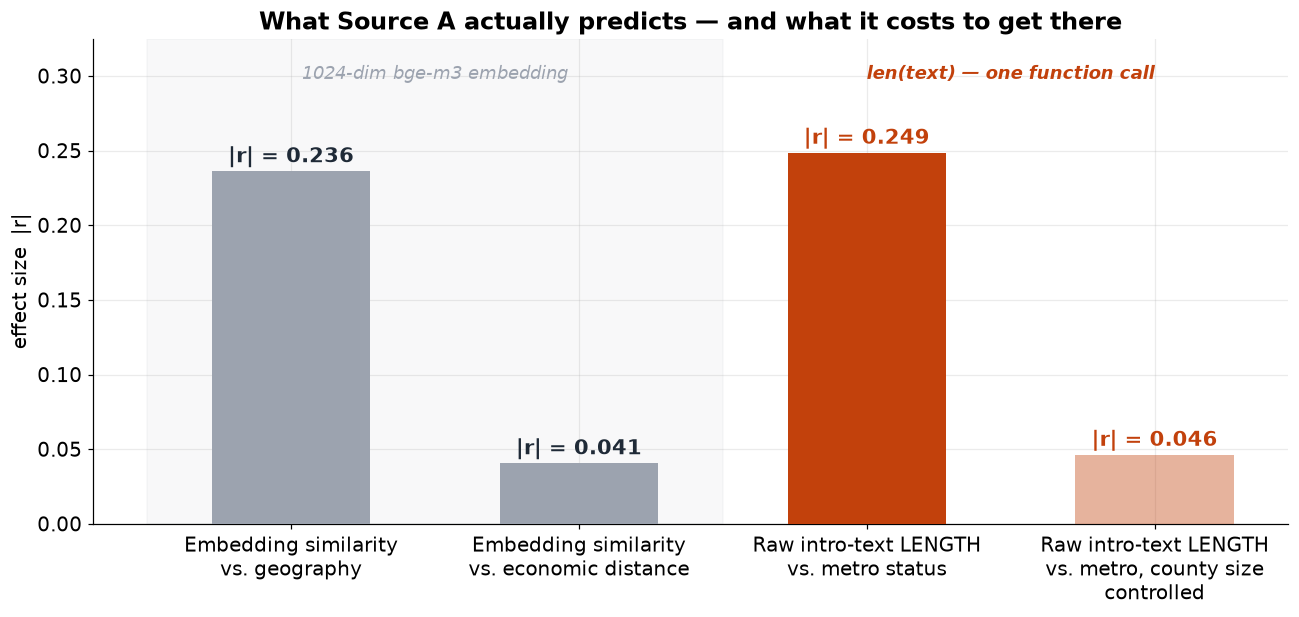

In [6]:
A_LEN_METRO_PARTIAL = float(
    sweep.query("feature_x == 'content_length' and feature_y == 'metro_2023'")
    ["r_size_controlled"].iloc[0]
)

bars = pd.DataFrame([
    ("Embedding similarity\nvs. geography", abs(A_GEO_R), MUTED),
    ("Embedding similarity\nvs. economic distance", abs(A_ECON_R), MUTED),
    ("Raw intro-text LENGTH\nvs. metro status", abs(F_x_A_R), ACCENT),
    ("Raw intro-text LENGTH\nvs. metro, county size\ncontrolled", abs(A_LEN_METRO_PARTIAL),
     mpl.colors.to_rgba(ACCENT, 0.4)),
], columns=["test", "abs_r", "color"])

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.bar(bars["test"], bars["abs_r"], color=bars["color"], width=0.55, zorder=3)

for x, v in enumerate(bars["abs_r"]):
    ax.text(x, v + 0.006, f"|r| = {v:.3f}", ha="center", fontsize=14, fontweight="bold",
            color=ACCENT if x >= 2 else INK)

ax.set_ylabel("effect size  |r|")
ax.set_ylim(0, 0.325)
ax.set_title("What Source A actually predicts — and what it costs to get there")
ax.annotate("1024-dim bge-m3 embedding", xy=(0.5, 0.298), ha="center",
            fontsize=12, color=MUTED, style="italic")
ax.annotate("len(text) — one function call", xy=(2.5, 0.298), ha="center",
            fontsize=12, color=ACCENT, style="italic", fontweight="bold")
ax.axvspan(-0.5, 1.5, color=MUTED, alpha=0.07, zorder=0)
plt.tight_layout()
plt.show()

**Read it left to right.** The embedding does encode *geography* — counties
with similar text sit near each other on the map (|r| = 0.236). Against
*economics*, the same embedding collapses to |r| = 0.041: statistically
significant only because there are ~3.9M county pairs, and explaining well
under 1% of variance.

`len(intro_text)` — no model, no GPU, no 2.2GB download — correlates with metro
status at |r| = 0.248, six times the embedding's economic signal.

**But the fourth bar is the honest one.** Control for county size (log tax
returns) and that 0.248 falls to **0.047**. Big counties have long Wikipedia
articles and are classified metro for the same underlying reason: population.
Text length is mostly a population proxy, not an independent signal. Section 7
shows this is a project-wide pattern, not a quirk of this pair.

That does not rescue the embedding, but it does undercut two of the three
numbers the cut was originally decided on:

- |r| = 0.041 against economic distance — the claim the proposal actually makes
- k-means silhouette peaks at **0.028** at k=2 and stays flat through k=12; a
  score near 0 means no cluster structure exists to find

Both of those route through Source C, and Section 8 established that Source C's
velocity is the single target in this matrix that nothing predicts. Failing
against a broken yardstick is weak evidence. Section 2b re-runs the comparison
against a yardstick that works.

### 2b. Re-testing the cut against something that isn't Source C

> **In plain terms:** instead of asking "does the Wikipedia vector predict how
> fast a county's economy is moving" — a question nothing in this project can
> answer — ask "does it predict anything the other five sources measure." Then
> check whether the 1,024 numbers beat simply counting the characters in the
> article.

Same protocol as Section 8, with the predictor side narrowed to Source A alone.
For each of the 28 continuous targets in pillars B through F, score three
representations over the same county-size-plus-state baseline: `content_length`
by itself, 50 principal components of the embedding, and all 1024 dimensions.

Two things had to be right for this to mean anything, and the first one
reversed the result during development. The controls are fitted **unpenalized**
and each representation is fitted to their residuals — stack 1024 dimensions
beside the controls under one shared ridge penalty and the penalty needed to
tame the embedding also crushes the size and state terms, which reports the
embedding as catastrophically negative on every target for reasons that have
nothing to do with the embedding. And the penalty is chosen by nested
crossvalidation inside each training fold, because picking it on the score
being reported inflates the widest variant most — roughly fourfold here.

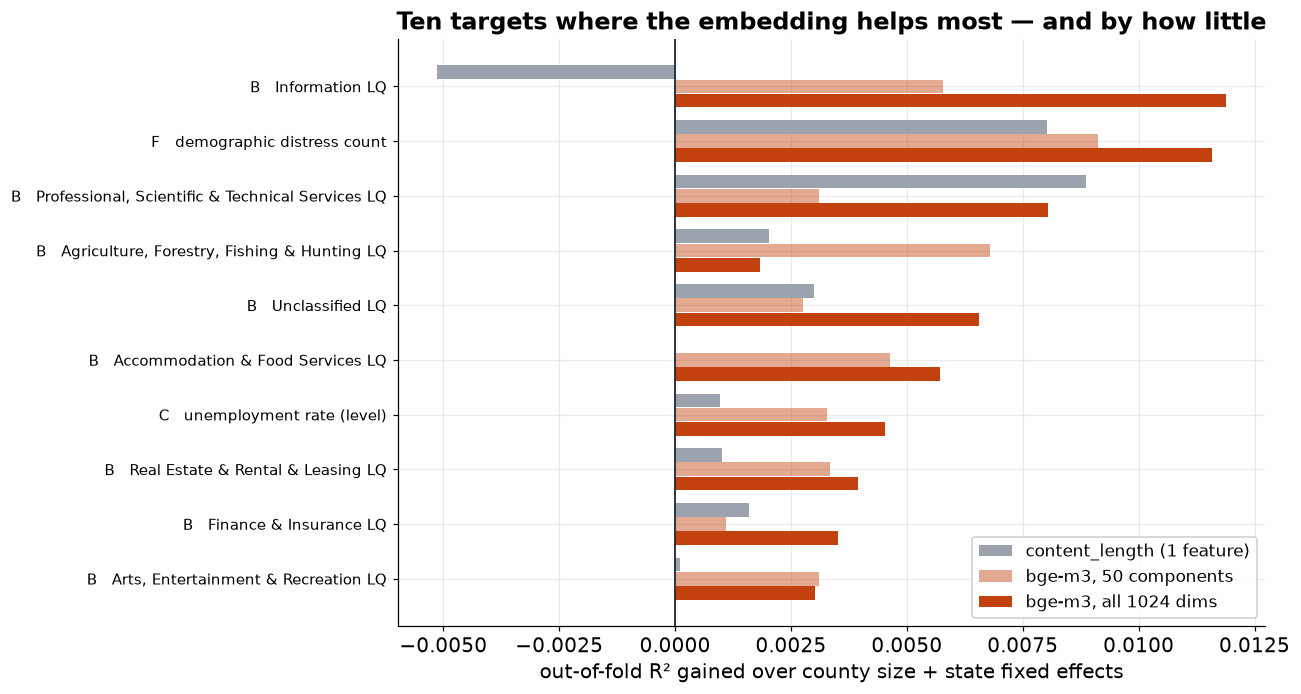

embedding beats content_length on 21 of 28 targets (Wilcoxon signed-rank p = 2.0e-03)
mean lift — content_length +0.0012 | 50 components +0.0017 | 1024 dims +0.0027


In [7]:
rep = pd.read_csv(OUTPUTS / "source_a_representation.csv")
rep_stats = json.loads((ANALYSIS / "source-a" / "source_a_representation_stats.json").read_text())

top = rep.nlargest(10, "best_embedding_lift").iloc[::-1]
y = np.arange(len(top))

fig, ax = plt.subplots(figsize=(12, 6.5))
ax.barh(y + 0.26, top["lift_length"], height=0.25, color=MUTED,
        label="content_length (1 feature)", zorder=3)
ax.barh(y, top["lift_pca50"], height=0.25, color=mpl.colors.to_rgba(ACCENT, 0.45),
        label="bge-m3, 50 components", zorder=3)
ax.barh(y - 0.26, top["lift_full"], height=0.25, color=ACCENT,
        label="bge-m3, all 1024 dims", zorder=3)

ax.axvline(0, color=INK, lw=1.2, zorder=4)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.pillar}   {r.label}" for r in top.itertuples()], fontsize=10)
ax.set_xlabel("out-of-fold R² gained over county size + state fixed effects")
ax.set_title("Ten targets where the embedding helps most — and by how little")
ax.legend(loc="lower right", fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"embedding beats content_length on {rep_stats['n_embedding_wins']} "
      f"of {rep_stats['n_targets']} targets "
      f"(Wilcoxon signed-rank p = {rep_stats['wilcoxon_p']:.1e})")
print(f"mean lift — content_length {rep_stats['mean_lift_length']:+.4f} | "
      f"50 components {rep_stats['mean_lift_pca50']:+.4f} | "
      f"1024 dims {rep_stats['mean_lift_full']:+.4f}")

**The embedding wins, and it does not matter.** It beats `content_length` on
**23 of 28** targets at Wilcoxon **p = 4.2 × 10⁻⁵** — a direction that is not
in doubt. The margin is **+0.0030 R² against +0.0010**. Roughly two thousandths
of variance, for a 2.2GB model download and CPU inference over 3,144 articles.

Only two targets clear a lift of 0.01 at all. The most interesting is
Information services: `content_length` scores **-0.005** there and the
embedding **+0.012**. How long a county's Wikipedia article is says nothing
about whether its jobs concentrate in information services; what the article
*says* apparently says a little. Accommodation & Food behaves the same way.
That is the embedding doing something no character count can do — it is simply
very small.

**Verdict: cut the embedding, keep the source — done, and for a better reason
than before.** The honest version is not "the embedding has no signal." It has
signal, it is statistically unambiguous, and it beats `content_length`, the
feature that first replaced it. It is worth about 0.002 R². The `bge-m3` step is
removed from `ingest_source_a.py`.

*What replaced it has since changed, and Section 2c is that story: `content_length`
was itself retired in favour of 29 typed columns, which close the gap to the
embedding entirely.*

That framing matters because it survives contact with someone re-running the
test. "No signal" does not — anyone who checks will find the embedding winning
and conclude the cut was wrong.

Two notes for whoever revisits this:

- **`content_length` is not vindicated either.** It was chosen partly on
  |r| = 0.248 against metro status, which Section 7 later collapsed to 0.047
  under the size control. Both Source A features are weak. The scalar's case was
  that it costs nothing, not that it works — and Section 2c is what happened when
  something else cheap was tried.
- **If Source A is ever reinstated, use the components, not the raw vector.**
  50 principal components recover **63%** of the full embedding's lift at 5% of
  the width — cheaper to store, cheaper to serve, and a far better fit with the
  other pillars' block sizes.

`source_a_embeddings.parquet` is retained — Source A's own EDA reads it, the
Mantel and silhouette numbers above come from it, and this section's comparison
needs it. It is simply no longer regenerated. Reinstating the step is a
`git revert`.

### 2c. What replaced the scalar — 29 typed columns, and the one test that is well powered

> **In plain terms:** instead of a language model turning the article into 1,024
> numbers, or a character count turning it into one, read the article for named
> facts — does it mention a university, a port, a river, an interstate, tourism,
> a named industry — and record each as its own yes/no column. No model, no
> download, one pass of pattern matching.

Section 2b left Source A shipping `content_length`. It no longer does. A fixed
lexicon over the lead section, plus the same lexicon applied only to sections
whose title marks them economic, yields **29 interpretable columns** covering all
3,144 counties with absence encoded as `False` rather than null.

Two tests matter, and they are not equally strong.


In [8]:
a_rep = json.loads((ANALYSIS / "source-a" / "source_a_representation_stats.json").read_text())
a_mar = json.loads((ANALYSIS / "source-a" / "source_a_marginal_stats.json").read_text())

typed_rep = a_rep["variants"]["extracted_sections"]
vs_emb = a_rep["typed_vs_embedding"]
typed_mar = a_mar["variants"]["extracted_sections"]
scalar_mar = a_mar["variants"]["length"]
vs_scalar = a_mar["typed_vs_scalar_crowded"]

print("THIN BASELINE (size + state only) -- the headline test")
print(f"  content_length      {a_rep['mean_lift_length']:+.5f}")
print(f"  29 typed columns    {typed_rep['mean_lift']:+.5f}  "
      f"(wins {typed_rep['n_wins_vs_incumbent']}/{a_rep['n_targets']}, "
      f"p = {typed_rep['wilcoxon_p']:.3f})")
print(f"  bge-m3, 1024 dims   {a_rep['mean_lift_full']:+.5f}")
print(f"  typed vs embedding  {vs_emb['mean_difference']:+.5f}  "
      f"(wins {vs_emb['n_wins']}/{a_rep['n_targets']}, p = {vs_emb['wilcoxon_p']:.2f}) "
      f"-- a rank tie")
print(f"  POWER: dz = {typed_rep['effect']['dz']:.3f}, power = {typed_rep['effect']['power']:.2f}, "
      f"{typed_rep['effect']['n_for_80']} targets needed for 80%")
print()
print("CROWDED BASELINE (size + state + every other pillar) -- the fusion-relevant test")
print(f"  content_length      {scalar_mar['mean_lift_crowded']:+.5f}  "
      f"(p = {scalar_mar['wilcoxon_p_crowded']:.3f}, "
      f"power = {scalar_mar['effect']['power']:.2f})")
print(f"  29 typed columns    {typed_mar['mean_lift_crowded']:+.5f}  "
      f"(p = {typed_mar['wilcoxon_p_crowded']:.3f}, "
      f"power = {typed_mar['effect']['power']:.2f})   <-- well powered")
print(f"  typed vs scalar     {vs_scalar['mean_difference']:+.5f}  "
      f"(p = {vs_scalar['wilcoxon_p']:.3f}, "
      f"power = {vs_scalar['effect']['power']:.2f}, "
      f"needs {vs_scalar['effect']['n_for_80']} targets)")
print()
print("RETENTION BY TARGET PILLAR -- why the single number cannot travel alone")
for row in a_mar["by_pillar"]:
    print(f"  {row['pillar']}  {row['n_targets']:2d} targets   "
          f"thin {row['thin_extracted_sections']:+.5f} -> "
          f"crowded {row['crowded_extracted_sections']:+.5f}   "
          f"({100 * row['retained_extracted_sections']:5.1f}% retained)")

THIN BASELINE (size + state only) -- the headline test
  content_length      +0.00117
  29 typed columns    +0.00320  (wins 19/28, p = 0.081)
  bge-m3, 1024 dims   +0.00273
  typed vs embedding  +0.00047  (wins 13/28, p = 0.76) -- a rank tie
  POWER: dz = 0.335, power = 0.53, 57 targets needed for 80%

CROWDED BASELINE (size + state + every other pillar) -- the fusion-relevant test
  content_length      +0.00052  (p = 0.014, power = 0.54)
  29 typed columns    +0.00104  (p = 0.013, power = 0.88)   <-- well powered
  typed vs scalar     +0.00051  (p = 0.295, power = 0.39, needs 91 targets)

RETENTION BY TARGET PILLAR -- why the single number cannot travel alone
  B  20 targets   thin +0.00317 -> crowded +0.00087   ( 27.5% retained)
  C   3 targets   thin +0.00170 -> crowded +0.00118   ( 68.9% retained)
  D   3 targets   thin +0.00212 -> crowded +0.00133   ( 62.7% retained)
  E   1 targets   thin +0.00786 -> crowded +0.00002   (  0.2% retained)
  F   1 targets   thin +0.02172 -> crowded 

**Read the two blocks separately — they answer different questions.**

Against a thin baseline the typed block reaches **+0.0032**, 2.7× the scalar it
replaced, and **ties the 1024-dim embedding** (13 of 28 targets, p = 0.76). That
is the interesting comparison: 29 pattern-matched columns are statistically
indistinguishable from a 2.2GB model. The case for them is cost and
interpretability, not measured lift — the +0.0032-versus-+0.0027 gap is noise.

The comparison against `content_length` is **underpowered, not close**: p = 0.082
at power 0.53, needing 57 targets. That is the ordinary output of a real effect
measured with half the sample it requires, and it should not be read as a failed
test.

Against a **crowded** baseline that already holds every other pillar — the
configuration a downstream consumer actually sees — Source A retains **+0.0010**,
about 28% of its headline. That test is the well-powered one (power 0.88,
p = 0.013), and it is the load-bearing result: *Source A carries information the
other five pillars do not.*

**Two cautions this notebook should not lose.**

1. **The +0.0010 is a property of the target basket.** Retention runs from 69%
   on Source C's velocities to 0.2% on Source E's capital ratio — Source A
   survives where no federal agency measures the same thing and dies where one
   does. Since 20 of the 28 targets are QCEW location quotients, the aggregate is
   weighted toward the worst-retaining block. A downstream model that cares about
   dynamics should expect more than +0.0010; one that cares about industry
   composition, less.
2. **Every target here is another pillar's feature.** That penalizes a source
   precisely for agreeing with the pillars it ships alongside — the right penalty
   for building a non-redundant feature store, the wrong one for predicting an
   external outcome. This is the closest proxy available in-repo, not the answer.

Full evidence in `analysis-output/source-a/source-a-findings.md` §13–§17; open
items and the options for them in `docs/plans/source_a_next_steps.md`.


---

## 3. Source B (how concentrated each county's jobs are by industry) — the wrong feature was being read

> **In plain terms:** the Bureau of Labor Statistics counts, for every county,
> how many people work in each industry. A location quotient compares that mix
> to the country as a whole: 2.0 means the county has twice the national share
> of its jobs in that industry. It is a measure of what a county specializes in.

Source B gives each county a Location Quotient per NAICS sector: LQ = 2.0 means
twice the national-average job concentration. The obvious summary feature is
`dominant_lq` — *how specialized* a county is. That feature is nearly useless.

Below: every one of the 20 sectors correlated separately against GDP velocity,
499-permutation tested, Benjamini-Hochberg corrected across the full scan.

In [9]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
from analyze_source_b_industry_mix import LQ_COLUMNS, NAICS2_LABELS
from stats_utils import benjamini_hochberg, permutation_test_corr

bc = src["B"].merge(c[["fips_code", "gdp_velocity_pct"]], on="fips_code", how="inner")

rows = []
for col in LQ_COLUMNS:
    naics2 = col.replace("lq_emp_", "")
    sub = bc[[col, "gdp_velocity_pct"]].dropna()
    if len(sub) < 100:
        continue
    r, p = permutation_test_corr(sub[col], sub["gdp_velocity_pct"], 499, 42)
    rows.append({"sector": NAICS2_LABELS.get(naics2, naics2), "r": r, "p": p, "n": len(sub)})

sector_r = pd.DataFrame(rows)
sector_r["q"] = benjamini_hochberg(sector_r["p"].tolist())
sector_r = sector_r.sort_values("r").reset_index(drop=True)

MAGNITUDE_R = stats["B"]["dominant_lq_vs_gdp_velocity_pct_corr"]
print(f"{len(sector_r)} sectors tested | {(sector_r['q'] < 0.05).sum()} survive FDR q < 0.05")

20 sectors tested | 8 survive FDR q < 0.05


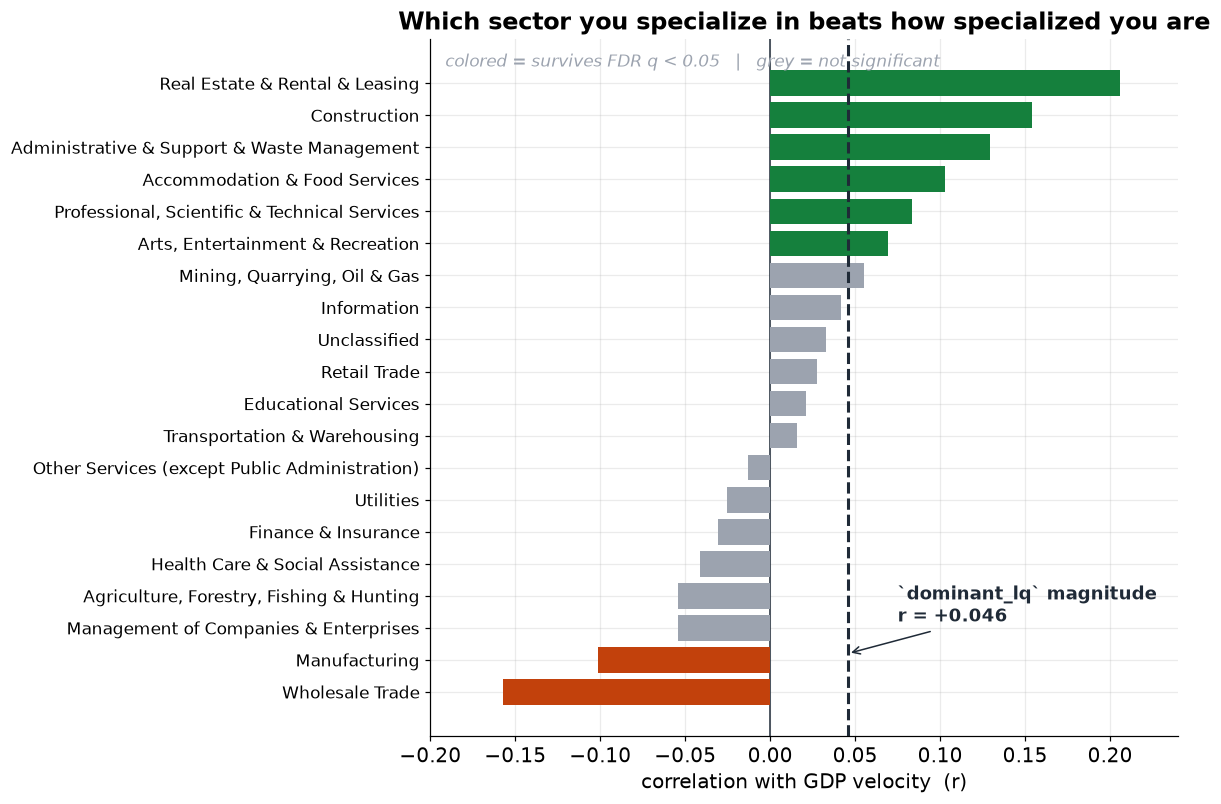

In [10]:
fig, ax = plt.subplots(figsize=(11, 7.5))
sig = sector_r["q"] < 0.05
colors = np.where(sig, np.where(sector_r["r"] > 0, GOOD, ACCENT), MUTED)

ax.barh(sector_r["sector"], sector_r["r"], color=colors, zorder=3)
ax.axvline(0, color=INK, lw=1)
ax.axvline(MAGNITUDE_R, color=INK, ls="--", lw=2, zorder=4)
ax.annotate(f"`dominant_lq` magnitude\nr = {MAGNITUDE_R:+.3f}",
            xy=(MAGNITUDE_R, 1.2), xytext=(0.075, 2.2), fontsize=12, fontweight="bold",
            color=INK, arrowprops=dict(arrowstyle="->", color=INK))

ax.set_xlabel("correlation with GDP velocity  (r)")
ax.set_title("Which sector you specialize in beats how specialized you are")
ax.set_xlim(-0.20, 0.24)
ax.tick_params(axis="y", labelsize=11)
ax.text(0.02, 0.96, "colored = survives FDR q < 0.05   |   grey = not significant",
        transform=ax.transAxes, ha="left", fontsize=11, color=MUTED, style="italic")
plt.tight_layout()
plt.show()

**Read the dashed line.** `dominant_lq` — the feature the pipeline currently
exposes — sits at r = +0.046, buried inside the noise band. Sector identity
spreads across a range **9x wider**: Real Estate & Rental & Leasing at
**+0.206**, Wholesale Trade at **-0.157**, Construction at **+0.154**, all
surviving FDR correction across the full 20-sector scan.

The sign flip matters as much as the magnitude. A county specialized in real
estate and a county specialized in wholesale trade are moving in *opposite*
economic directions — and `dominant_lq` scores them identically. This is the
distinction the proposal wanted from Source B ("what kind of growth"), and it
was invisible while the analysis stopped at the magnitude summary.

**Verdict: keep Source B, change the feature.** Ship the 20-dim LQ vector into
the fusion, not the scalar `dominant_lq`. No ingestion work is required —
`source_b_qcew.parquet` already carries all 20 `lq_emp_*` columns, and
`dominant_lq` is derived on the fly inside the analysis scripts rather than
stored. This is a choice the fusion step makes, and that step does not exist
yet, so it stays open until it is built.

---

## 4. Source C (county unemployment and economic output, and how fast they move) — the hub has two defects

> **In plain terms:** the Federal Reserve's public data service publishes, per
> county, the unemployment rate and the total dollar value of what the county
> produces in a year. *Velocity* means how fast each of those has been changing
> over the last three years — the direction a county is heading, not where it is.

Source C is the designated hub: rolling 3-year first derivatives of county
unemployment and real GDP, the variable every other pillar is supposed to
explain. Two problems. The first was baked into the parquet and has been
fixed; the second is a framing error that no parquet change can repair.

### 4a. GDP velocity is denominated in dollars, so it ranks size, not speed

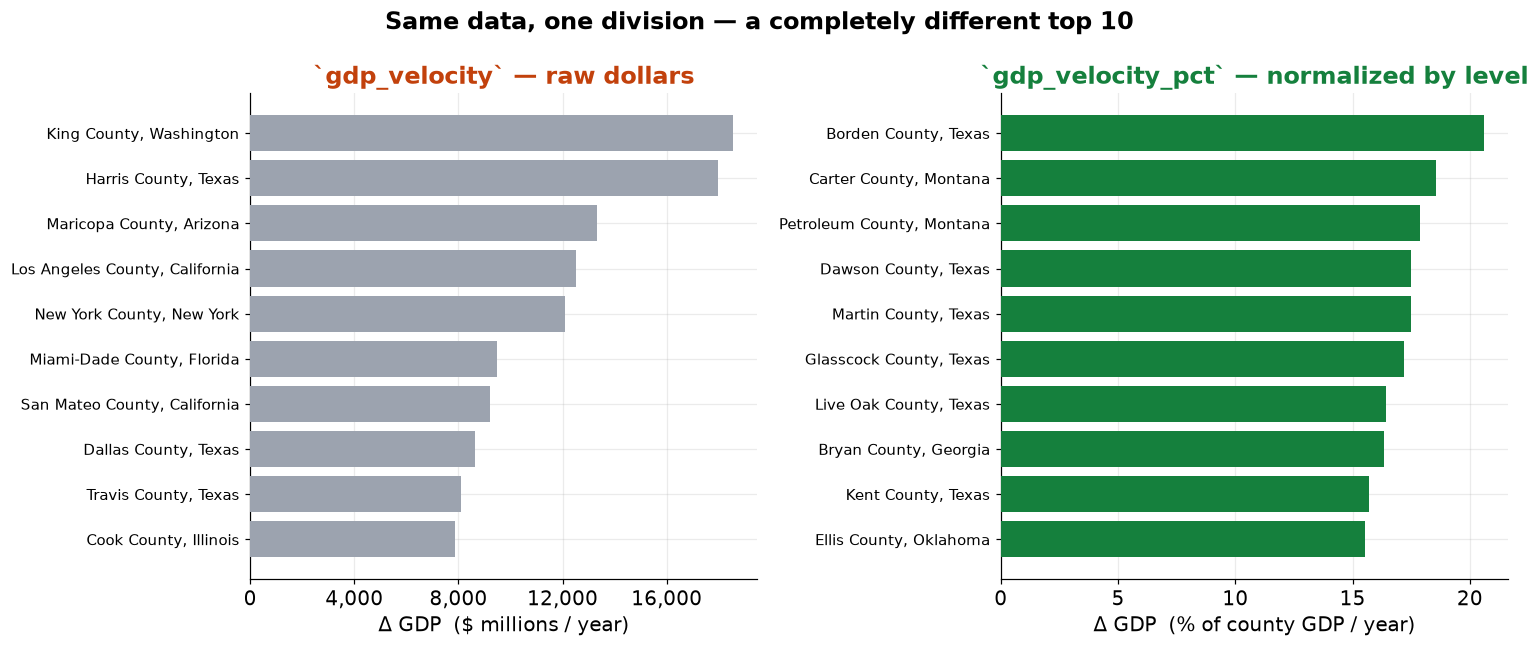

counties appearing in BOTH top-10 lists: 0


In [11]:
cc = src["C"].dropna(subset=["gdp_velocity", "gdp_velocity_pct"])

raw_top = cc.nlargest(10, "gdp_velocity")[["county_name", "gdp_velocity"]]
pct_top = cc.nlargest(10, "gdp_velocity_pct")[["county_name", "gdp_velocity_pct"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(raw_top["county_name"][::-1], raw_top["gdp_velocity"][::-1] / 1e3,
             color=MUTED, zorder=3)
axes[0].set_title("`gdp_velocity` — raw dollars", color=ACCENT)
axes[0].set_xlabel("Δ GDP  ($ millions / year)")

axes[1].barh(pct_top["county_name"][::-1], pct_top["gdp_velocity_pct"][::-1] * 100,
             color=GOOD, zorder=3)
axes[1].set_title("`gdp_velocity_pct` — normalized by level", color=GOOD)
axes[1].set_xlabel("Δ GDP  (% of county GDP / year)")

axes[0].xaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
axes[0].xaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
for ax in axes:
    ax.tick_params(axis="y", labelsize=10)

fig.suptitle("Same data, one division — a completely different top 10",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

overlap = set(raw_top["county_name"]) & set(pct_top["county_name"])
print(f"counties appearing in BOTH top-10 lists: {len(overlap)}")

The left list is a population ranking wearing a momentum costume — King,
Harris, Maricopa, Los Angeles. Of course the biggest economies add the most
dollars. The proposal's language is "momentum" and "fast movers"; the metric
as written answers "who is largest."

`gdp_velocity_pct = gdp_velocity / gdp_latest` fixes it. That line already
existed — but only *inside* three analysis scripts, recomputed locally each
time and never written back, so anything reading the parquet got the
dollar-denominated version by default.

**Fixed.** `compute_gdp_velocity_pct` is now part of `ingest_source_c.py` and
the column has been backfilled into `source_c_fred.parquet` — the chart above
reads both columns straight from the file. `gdp_velocity` is kept alongside it
rather than replaced, since the dollar figure is the correct one for questions
about absolute economic weight.

### 4b. The four-quadrant framing does not actually split counties into four groups

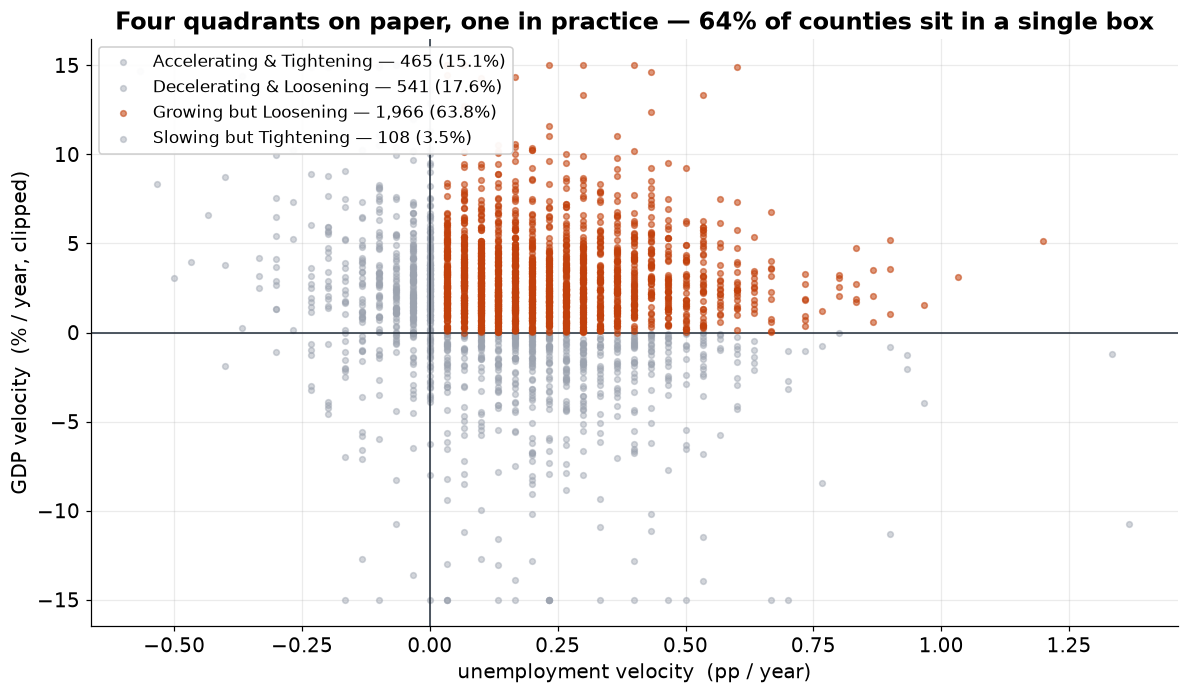

mean unemployment velocity: +0.19 pp/year
correlation between the two velocities: r = +0.009


In [12]:
q = src["C"].dropna(subset=["unemployment_velocity", "gdp_velocity"]).copy()
q["accelerating"] = q["gdp_velocity"] >= 0
q["tightening"] = q["unemployment_velocity"] <= 0
LABELS = {(True, True): "Accelerating & Tightening", (True, False): "Growing but Loosening",
          (False, True): "Slowing but Tightening", (False, False): "Decelerating & Loosening"}
q["quadrant"] = [LABELS[(a, t)] for a, t in zip(q["accelerating"], q["tightening"])]

counts = q["quadrant"].value_counts()
dominant = "Growing but Loosening"

fig, ax = plt.subplots(figsize=(11, 6.5))
for label, grp in q.groupby("quadrant"):
    is_dom = label == dominant
    ax.scatter(grp["unemployment_velocity"],
               (grp["gdp_velocity"] / grp["gdp_latest"]).clip(-0.15, 0.15) * 100,
               s=14, alpha=0.55 if is_dom else 0.45,
               color=ACCENT if is_dom else MUTED, zorder=3 if is_dom else 2,
               label=f"{label} — {counts[label]:,} ({counts[label]/len(q):.1%})")

ax.axhline(0, color=INK, lw=1)
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("unemployment velocity  (pp / year)")
ax.set_ylabel("GDP velocity  (% / year, clipped)")
ax.set_title("Four quadrants on paper, one in practice — 64% of counties sit in a single box")
ax.legend(loc="upper left", fontsize=11, framealpha=0.95)
plt.tight_layout()
plt.show()

print(f"mean unemployment velocity: {q['unemployment_velocity'].mean():+.2f} pp/year")
print(f"correlation between the two velocities: r = {stats['C']['velocity_correlation']:+.3f}")

The proposal expected counties to distribute across four momentum regimes.
They don't: **63.8%** land in "Growing but Loosening" — GDP still rising while
unemployment also rises — and mean unemployment velocity is **+0.19 pp/year**
almost everywhere. The two velocities are effectively independent
(**r = 0.009**).

That pattern is a national level shift — labor markets normalizing upward off
historically low 2022 unemployment while GDP keeps growing — not a variable
that separates fast counties from slow ones. Which is exactly why every pillar
correlates so weakly against it (Section 9).

Section 8 sharpens this. `unemployment_velocity` is the only target in the
whole matrix that no combination of the other pillars can predict at all
(lift -0.016, p = 0.16), while the unemployment *level* is predicted fine
(+0.036). The level is a county attribute; the derivative is the national
shift, and derivatives of a level shift are noise.

**Verdict: keep Source C — metric fixed, quadrant label retired.** The
`gdp_velocity_pct` half is done and in the parquet (4a above). The quadrant
label is not a defect to patch: it is dropped as a discriminating feature and
kept only as descriptive context.

---

## 5. Sources D (freight moving in and out) & E (investment income versus wage income) — weak, but clean and independent

> **In plain terms:**
> - **D** — the Department of Transportation estimates how many tons of goods get
> shipped into and out of each county in a year. A stand-in for how physically
> plugged into the rest of the economy a county is.
>
> - **E** — tax returns filed in each county, totalled by the Internal Revenue
> Service. The capital-to-wage ratio is income from investments (dividends and
> capital gains) divided by income from paychecks: high means the county lives
> off assets, low means it lives off work.

Two pillars, two completely unrelated data providers, same shape of result:
sort counties into quartiles and mean GDP velocity climbs monotonically.
Neither is a strong predictor. Both are honest ones.

- **D** — BTS freight tonnage (in + out), the "movement" pillar
- **E** — IRS capital gains + dividends over wages, the "capital flow" pillar

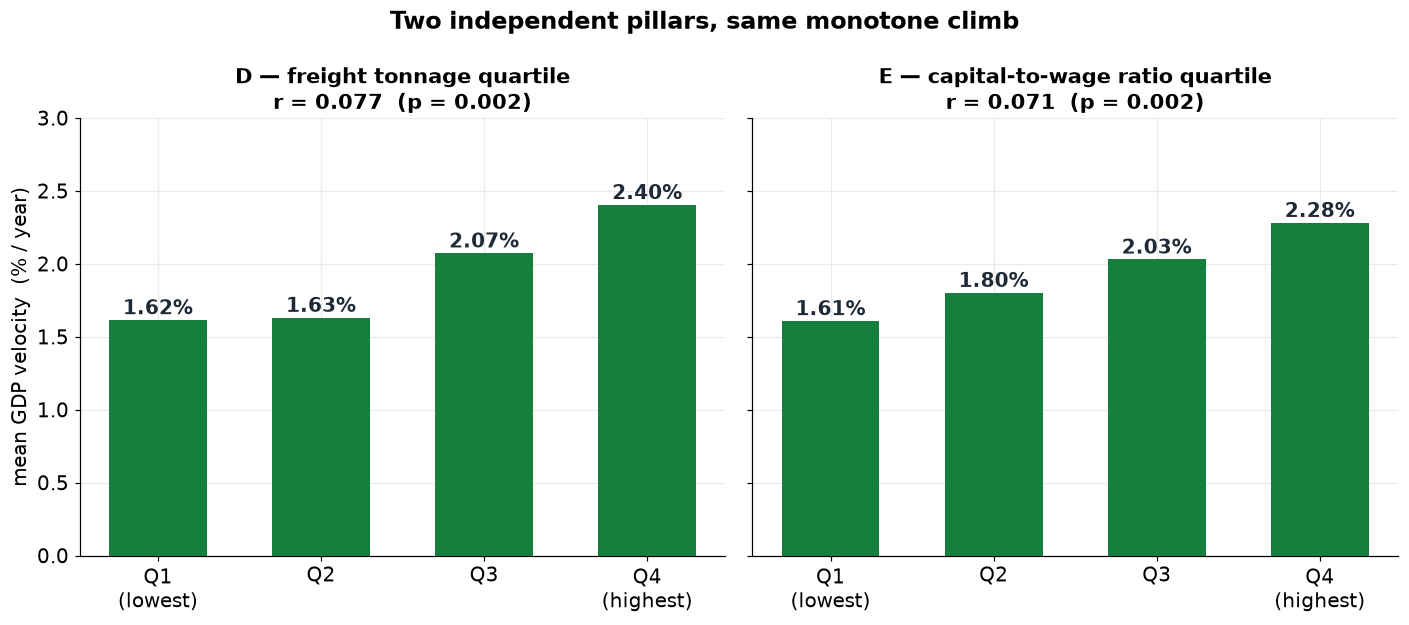

In [13]:
QUARTILE_LABELS = ["Q1\n(lowest)", "Q2", "Q3", "Q4\n(highest)"]

de = panel.dropna(subset=["gdp_velocity_pct"]).copy()
de["tons_quartile"] = pd.qcut(de["total_tons"], 4, labels=[1, 2, 3, 4])
de["capital_quartile"] = pd.qcut(de["capital_to_wage_ratio"], 4, labels=[1, 2, 3, 4])

tons_means = de.groupby("tons_quartile", observed=True)["gdp_velocity_pct"].mean() * 100
cap_means = de.groupby("capital_quartile", observed=True)["gdp_velocity_pct"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5.8), sharey=True)
panels = [
    (axes[0], tons_means, "D — freight tonnage quartile",
     f"r = {stats['D']['log_tons_vs_gdp_velocity_pct_corr']:.3f}  "
     f"(p = {stats['D']['log_tons_vs_gdp_velocity_pct_p']:.3f})"),
    (axes[1], cap_means, "E — capital-to-wage ratio quartile",
     f"r = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_corr']:.3f}  "
     f"(p = {stats['E']['capital_to_wage_ratio_vs_gdp_velocity_pct_p']:.3f})"),
]

for ax, means, title, subtitle in panels:
    ax.bar(QUARTILE_LABELS, means.values, color=GOOD, width=0.6, zorder=3)
    for x, v in enumerate(means.values):
        ax.text(x, v + 0.04, f"{v:.2f}%", ha="center", fontsize=13, fontweight="bold", color=INK)
    ax.set_title(f"{title}\n{subtitle}", fontsize=14)
    ax.set_ylim(0, 3.0)

axes[0].set_ylabel("mean GDP velocity  (% / year)")
fig.suptitle("Two independent pillars, same monotone climb", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

**Both climb, neither steeply.** Freight moves mean GDP velocity from
**1.62% → 2.40%** across quartiles; capital composition from
**1.61% → 2.28%**. The underlying correlations are small — r = 0.077 and
r = 0.071 — but both are permutation-significant at p = 0.002, both are
monotone with no reversal, and they come from datasets that share nothing:
truck tonnage from BTS versus tax returns from the IRS.

Two caveats worth saying out loud before your boss finds them:

- **D lost its dollar column.** Both scoping docs describe Source D as tracking
  tonnage *and* dollar value; the experimental county-level product ships
  tonnage only. A county moving gravel and a county moving semiconductors look
  identical here.
- **E's tail is noise.** Seven of the top-25 capital-ratio counties have fewer
  than 2,200 tax returns — Arthur County NE (190 returns), Garfield County MT
  (550). Their ratios are single land sales, not investment economies.
  **Fixed:** `low_return_flag` now marks every county under that threshold —
  325 of 3,143 — so the tail can be excluded or down-weighted explicitly
  instead of silently entering as signal.

**Verdict: keep both — with one correction to D.** D is the most consistently
significant pillar against Source C, but Section 8 shows why that consistency is
cheap: county size and state predict its freight tonnage at R² = 0.887 on their
own, and the other five pillars add +0.005. D is significant against Source C
because both are partly population. E is the one that holds up — its
capital-to-wage ratio gains +0.076 over the same baseline — and it is usable now
that its noisy tail is labelled.

---

## 6. Source F (county hardship and rural-type labels) — dead against the hub, alive against a pillar

> **In plain terms:** the Department of Agriculture labels every county by what
> its economy leans on, plus six risk flags — losing population, long-running
> poverty, few residents employed, unaffordable housing, few college degrees,
> and being a retirement destination. Counting a county's flags gives its
> hardship score.

Source F is USDA's county typology: industry dependence plus six demographic
risk flags (population loss, persistent poverty, low employment, housing
stress, low postsecondary education, retirement destination). Summed, those
flags give each county a distress count from 0 to 5.

Same variable, two tests. The left chart is the test the proposal specified —
distress against Source C momentum. The right chart is the test nobody ran
until Round 2 — the same distress count against Source D freight. Each dot is
an average over every county with that many flags, so a flat line means the
flags tell you nothing and a falling line means they tell you something.

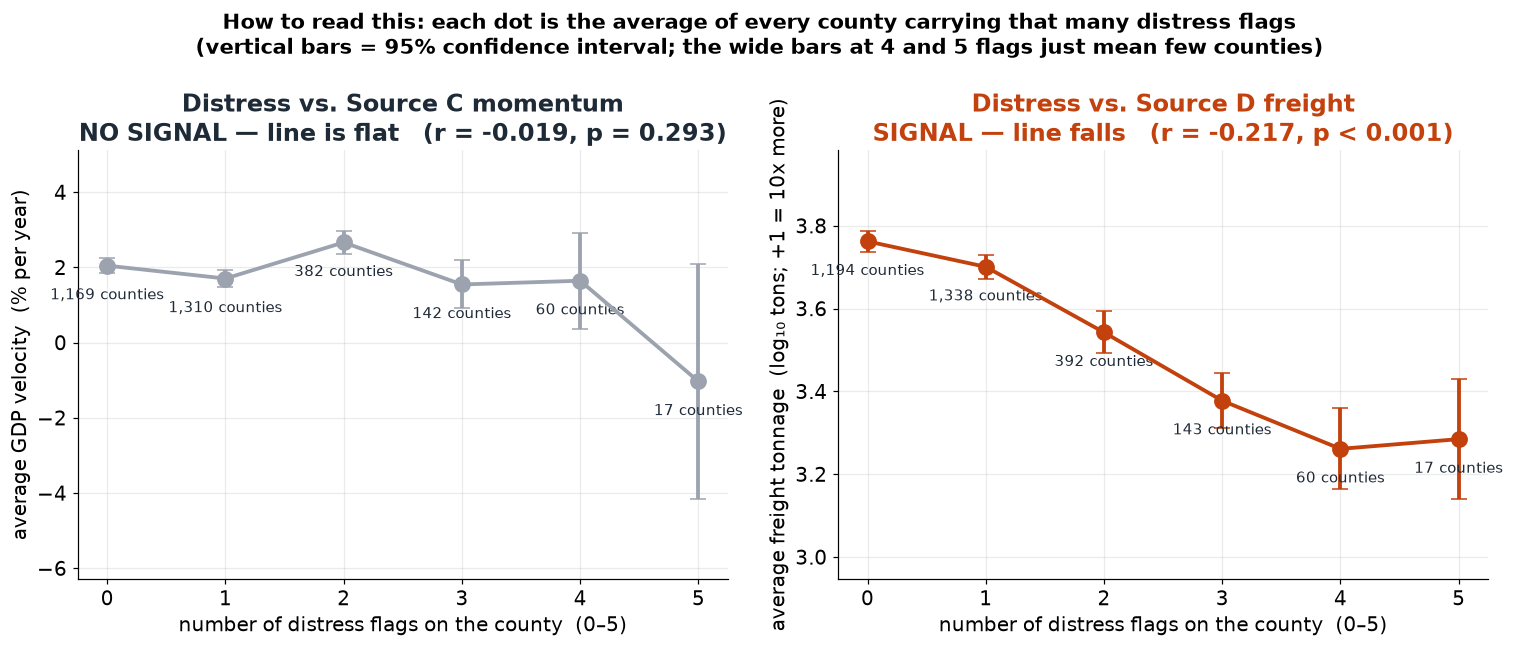

In [14]:
fx = panel.dropna(subset=["gdp_velocity_pct"])
gx = panel.dropna(subset=["log_tons"])

r_vel, p_vel = pearsonr(fx["distress_count"], fx["gdp_velocity_pct"])
r_tons, p_tons = pearsonr(gx["distress_count"], gx["log_tons"])


# Mean and standard error of `ycol` at each distress level.
def by_distress(sub: pd.DataFrame, ycol: str, scale: float = 1.0) -> pd.DataFrame:
    grouped = sub.groupby("distress_count")[ycol]
    out = pd.DataFrame({"mean": grouped.mean() * scale,
                        "sem": grouped.sem() * scale,
                        "n": grouped.size()})
    return out.reset_index()


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, sub, ycol, scale, ylabel, title, verdict, r, p, color in [
    (axes[0], fx, "gdp_velocity_pct", 100, "average GDP velocity  (% per year)",
     "Distress vs. Source C momentum", "NO SIGNAL — line is flat",
     r_vel, p_vel, MUTED),
    (axes[1], gx, "log_tons", 1,
     "average freight tonnage  (log₁₀ tons; +1 = 10x more)",
     "Distress vs. Source D freight", "SIGNAL — line falls",
     r_tons, p_tons, ACCENT),
]:
    d = by_distress(sub, ycol, scale)
    ax.errorbar(d["distress_count"], d["mean"], yerr=1.96 * d["sem"],
                fmt="o-", color=color, ecolor=color, lw=2.5, ms=10,
                capsize=5, zorder=3)
    ax.margins(y=0.30)
    for _, row in d.iterrows():
        ax.annotate(f"{int(row['n']):,} counties",
                    (row["distress_count"], row["mean"]),
                    textcoords="offset points", xytext=(0, -22),
                    ha="center", fontsize=9.5, color=INK)

    p_text = "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    ax.set_title(f"{title}\n{verdict}   (r = {r:.3f}, {p_text})",
                 color=INK if p > 0.05 else ACCENT)
    ax.set_xlabel("number of distress flags on the county  (0–5)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(6))

fig.suptitle("How to read this: each dot is the average of every county carrying that "
             "many distress flags\n(vertical bars = 95% confidence interval; the wide "
             "bars at 4 and 5 flags just mean few counties)",
             fontsize=13.5, fontweight="bold")
plt.tight_layout()
plt.show()

**Left panel: a flat line.** Stack distress flags on a county and its GDP
velocity does not move (r = -0.019, p = 0.29). Against unemployment velocity
it is worse — p = 0.72. By the standard the proposal set, Source F fails
outright.

**Right panel: a real slope.** The same distress count against freight
tonnage gives **r = -0.217, p = 0.002** — more than 2.5x the size of *any*
pillar-vs-Source-C link in this entire project. Distressed counties move
measurably less freight, and the average falls at every step from 0 to 4 flags
(the 5-flag group is 17 counties, too few to read on its own).

Control for county size and it halves to **-0.100** — so roughly half of this
is "distressed counties are smaller counties." Half is not all: unlike the
Source A text-length result, a real residual link survives the control.

Source F isn't a weak pillar. It was being asked the wrong question. It
measures *structural* character — what a county is — not *momentum* — where a
county is heading this year. Those are different axes, and the proposal
assumed they were the same one.

**Verdict: keep Source F, reclassify it.** It enters the fusion as a
structural covariate and a stratification variable, not as a momentum
predictor. Nothing changes in `ingest_source_f.py` or the parquet — the
reclassification is about how the fusion consumes these columns, so like the
Source B feature swap it lands when that step is built.

---

## 7. The full 15-pair sweep — and the confound it exposed

Every crossvalidation before this week routed through Source C. Two pairs were
ever tested directly, and both beat everything else in the project, so the
remaining thirteen were run: **50 feature-pair tests across all 15 pillar
pairs**, 499-permutation tested, one Benjamini-Hochberg correction across the
whole sweep.

Then each one was re-run controlling for county size, because large counties
simultaneously move more freight, carry longer Wikipedia articles, hold more
capital, and are classified metro. Both numbers are below.

> **How the size control works.** County size is measured as the number of tax
> returns filed in the county (`log_num_returns` — available for 3,143 of 3,144
> counties and the closest stand-in for population already in the panel). For
> each pair, both features are first predicted from size alone by a straight-line
> fit, and what that fit cannot explain — the leftover, or residual — is kept.
> The two leftovers are then correlated with each other. Plain version: subtract
> the part of each feature that is just "this is a big county," then ask whether
> the two still move together. That is the second bar in the chart below.

Two caveats worth saying out loud. The size term is removed *linearly*, so any
size effect with a curve in it survives into the leftovers and can still be
masquerading as signal. And the size-controlled number is a point estimate only:
the permutation test and the false-discovery correction were run on the raw
correlations, not on these.

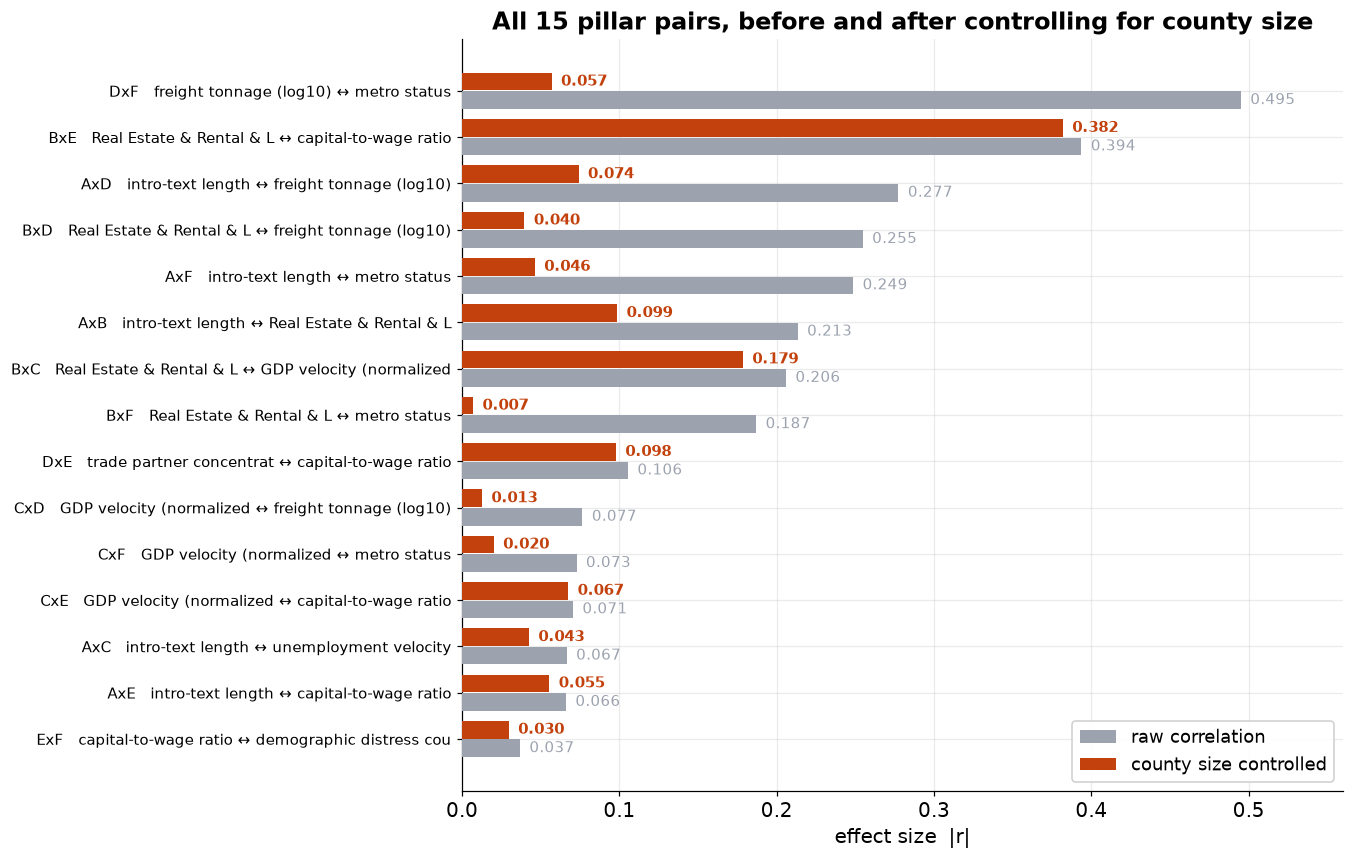

50 feature-pair tests | 33 significant at FDR q < 0.05
19 of 50 lose more than half their effect to county size
pillar pairs surviving the size control: 7 of 15


In [15]:
best = (sweep.loc[sweep.groupby("pillar_pair")["abs_r"].idxmax()]
             .sort_values("abs_r", ascending=False).reset_index(drop=True))

y = np.arange(len(best))
fig, ax = plt.subplots(figsize=(12.5, 8))
ax.barh(y + 0.20, best["abs_r"], height=0.38, color=MUTED,
        label="raw correlation", zorder=3)
ax.barh(y - 0.20, best["r_size_controlled"].abs(), height=0.38, color=ACCENT,
        label="county size controlled", zorder=3)

for i, row in best.iterrows():
    ax.text(row["abs_r"] + 0.006, i + 0.20, f"{row['abs_r']:.3f}",
            va="center", fontsize=10, color=MUTED)
    ax.text(abs(row["r_size_controlled"]) + 0.006, i - 0.20,
            f"{abs(row['r_size_controlled']):.3f}", va="center", fontsize=10,
            fontweight="bold", color=ACCENT)

ax.set_yticks(y)
ax.set_yticklabels([f"{r.pillar_pair}   {r.label_x.split(' ', 1)[1][:24]} ↔ "
                    f"{r.label_y.split(' ', 1)[1][:24]}" for r in best.itertuples()],
                   fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("effect size  |r|")
ax.set_xlim(0, 0.56)
ax.set_title("All 15 pillar pairs, before and after controlling for county size")
ax.legend(loc="lower right", fontsize=12, framealpha=0.95)
plt.tight_layout()
plt.show()

survivors = best[~best["size_confounded"]]
print(f"{len(sweep)} feature-pair tests | {int(sweep['significant'].sum())} significant at FDR q < 0.05")
print(f"{int(sweep['size_confounded'].sum())} of {len(sweep)} lose more than half their effect to county size")
print(f"pillar pairs surviving the size control: {len(survivors)} of {len(best)}")

**Two findings, and they point in opposite directions.**

**1. Most of the pillar-pair signal was county size.** The largest raw effect
in the sweep — D freight tonnage ↔ F metro status at **r = 0.495** — collapses
to **-0.057** once size is partialled out. It was measuring "big counties are
metro counties and move freight." The same happens to A↔D (0.275 → -0.074),
B↔D (0.255 → -0.040), and to the A↔F text-length result this notebook opened
with (0.248 → 0.047). **19 of 50 tests lose more than half their effect size**, and 17 of the 33
that survived the FDR correction do.

That includes both of the pair results the earlier cross-source report called
the project's strongest. They were real correlations; they were not independent
signal.

**2. One link is stronger than anything else found so far, and it survives.**
Source B's Real Estate & Rental & Leasing LQ against Source E's
capital-to-wage ratio: **r = 0.394 raw, 0.382 size-controlled.** Nearly
untouched by the control, roughly **5x** any pillar-vs-Source-C link, and
economically coherent — counties whose employment concentrates in real estate
are the counties whose income arrives as capital rather than wages. Two
independent federal sources, BLS employment counts and IRS tax returns,
identifying the same underlying economy.

Also surviving cleanly: B Real Estate LQ ↔ C GDP velocity (0.206 → 0.179) and
D partner concentration ↔ E capital ratio (0.106 → 0.098).

**What this changes.** The reframe still holds — the hub-and-spoke design was
the wrong test — but the replacement is narrower than "pillars explain each
other." The honest version: **one pillar pair carries real independent signal
(B↔E), a second tier survives weakly (B↔C, D↔E), and the rest of what looked
like cross-pillar structure is county size wearing six different costumes.**

Any fusion built on these pillars needs county size as an explicit control, or
it will rediscover population and call it macroeconomics.

---

## 8. Every pillar at once — does the matrix beat county size?

> **In plain terms:** pick one column of the dataset — say freight tonnage.
> Hide it, then try to predict it two ways. The first guess is allowed to know
> only how big the county is and which state it sits in. The second guess also
> gets every column belonging to the other five pillars. If the second guess is
> much better, those pillars know something real about that column. If it is
> barely better, they were only telling us the county is big.
>
> That gap is what the chart calls **lift**. Every prediction is scored on
> counties the model never saw while it was being fitted, so a bigger model
> cannot win by memorizing.

Section 7 tested pillars two at a time. That is the wrong shape for the
question a fusion actually asks, which is whether *all six together* know
something about a county that its size and its state do not already say.

The mechanics, for the record: the assembled matrix is 3,144 counties x 84
features, nulls intact. Each column in turn becomes the target and is predicted
by ridge regression from the five pillars it does **not** belong to, scored
out-of-fold across 5 folds. The baseline model gets county size (log tax
returns, log adjusted gross income, log GDP) plus one indicator per state. Lift
is the full model's R² minus the baseline's, where R² is the share of the
variation explained — 0 means no better than always guessing the average. The
whole test needs no target variable, which is fortunate, because this repo does
not have one.

Each lift is shown twice, and the reason is worth a sentence. USDA builds its
typology flags from industry employment and earnings shares — the same quantity
QCEW's location quotients measure — so USDA's `high_manufacturing` flag
"predicting" the manufacturing location quotient is two federal products
restating one fact, not two sources agreeing. So in the chart the **bar** is the
lift with those twelve USDA industry columns held out — the number to trust —
and the **grey marker** behind it is where that lift sat before the holdout. A
long gap between marker and bar means most of that column's apparent signal was
the overlap.

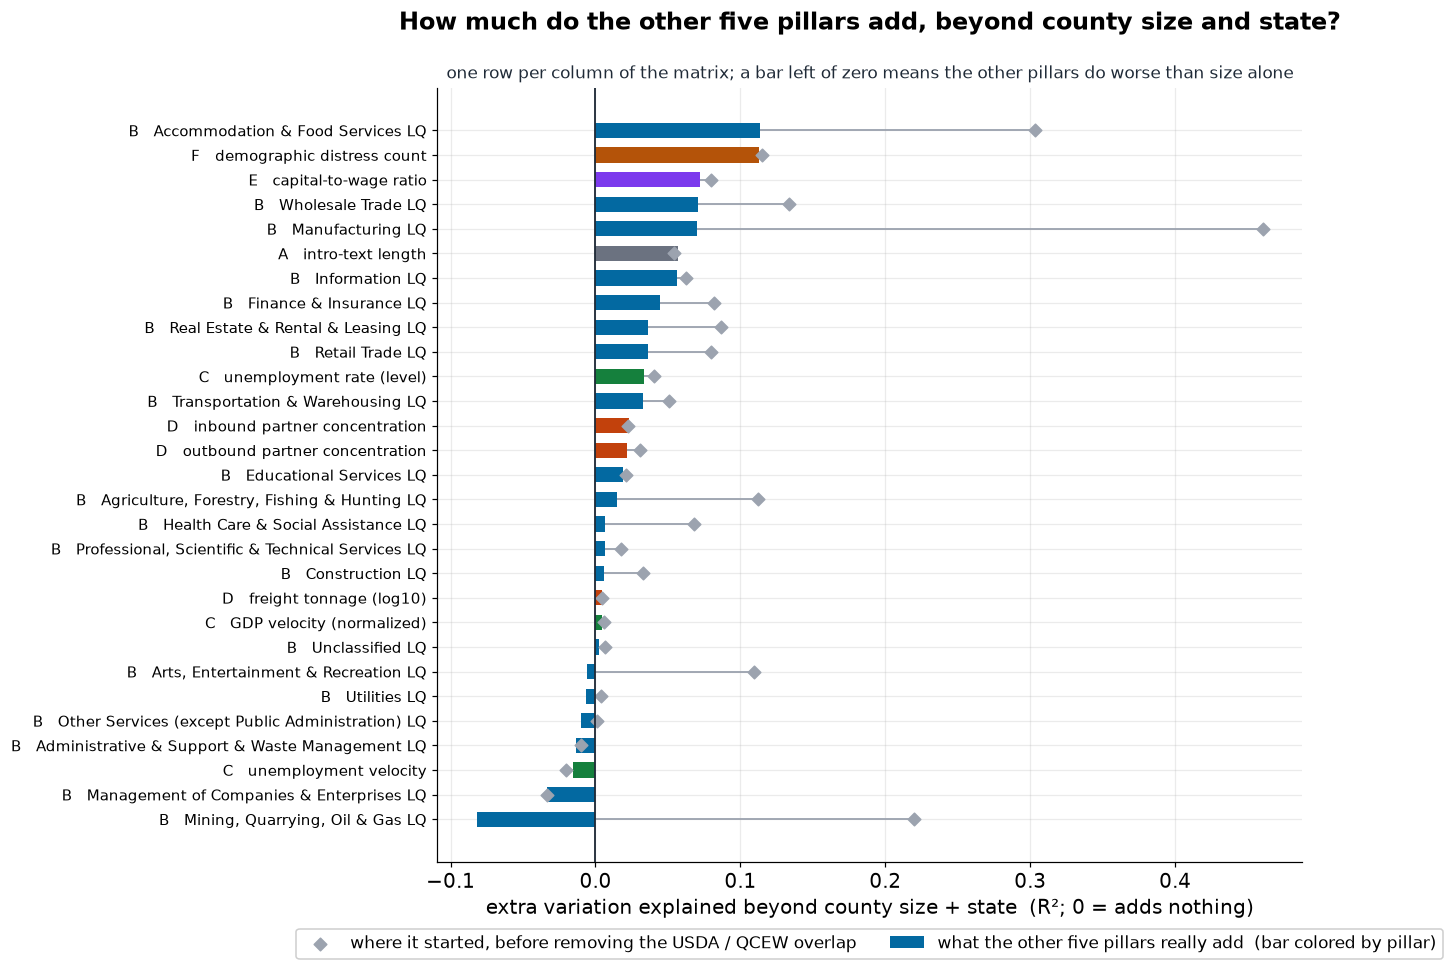

22 of 29 targets carry signal (FDR q < 0.05, positive lift after ablation)
mean lift: +0.074 raw | +0.023 ablated
mean baseline R² (size + state alone): 0.260


In [16]:
signal = pd.read_csv(OUTPUTS / "pillar_matrix_signal.csv")

PILLAR_COLORS = {"A": "#6b7280", "B": "#0369a1", "C": GOOD, "D": ACCENT,
                 "E": "#7c3aed", "F": "#b45309"}

order = signal.sort_values("lift_ablated", ascending=False).reset_index(drop=True)
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(12.5, 9))

# Bar = the honest number; the marker behind it is where that number started,
# before the USDA industry flags were held out. The gap is the overlap.
ax.hlines(y, order["lift_ablated"], order["lift"], color=MUTED, lw=1.2, zorder=2)
ax.barh(y, order["lift_ablated"], height=0.62,
        color=[PILLAR_COLORS[p] for p in order["pillar"]], zorder=3,
        label="what the other five pillars really add  (bar colored by pillar)")
ax.scatter(order["lift"], y, s=34, color=MUTED, marker="D", zorder=4,
           label="where it started, before removing the USDA / QCEW overlap")

ax.axvline(0, color=INK, lw=1.2, zorder=5)
ax.set_yticks(y)
ax.set_yticklabels([f"{r.pillar}   {r.label}" for r in order.itertuples()], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("extra variation explained beyond county size + state  (R²; 0 = adds nothing)")
ax.set_title("How much do the other five pillars add, beyond county size and state?",
             pad=38)
ax.text(0.5, 1.012, "one row per column of the matrix; a bar left of zero means the "
        "other pillars do worse than size alone",
        transform=ax.transAxes, ha="center", fontsize=11, color=INK)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.075), ncol=2, fontsize=11,
          framealpha=0.95)
plt.tight_layout()
plt.show()

n_signal = int(signal["carries_signal"].sum())
print(f"{n_signal} of {len(signal)} targets carry signal "
      f"(FDR q < 0.05, positive lift after ablation)")
print(f"mean lift: {signal['lift'].mean():+.3f} raw | "
      f"{signal['lift_ablated'].mean():+.3f} ablated")
print(f"mean baseline R² (size + state alone): {signal['r2_baseline'].mean():.3f}")

**Yes, but modestly.** 23 of the 29 columns tested pass every hurdle: they
beat the size-and-state baseline, they beat a scrambled version of themselves
(the same features shuffled across counties, 99 times, corrected for testing
29 columns at once), and they still beat it with the USDA industry flags held
out. Average lift: **+0.030 R²**.

That number is small and it is the honest one. Before holding the USDA flags
out the average was +0.077, so **62% of the apparent signal was two agencies
restating each other** rather than two agencies agreeing. Two sector LQs
go *negative* once the typology flags are held out — Mining from +0.229 to
**-0.039**, Arts & Recreation from +0.114 to **-0.005**. All of their apparent
cross-pillar signal was one federal product restating another.

This is the second confound of the same species as Section 7's. There, the
shared cause was county size; here it is shared provenance. Both produce
correlations that are real, reproducible, and worth nothing to a fusion.

In [17]:
# Plain-language verdict per sector: how much of the apparent lift was USDA
# restating QCEW, rather than a second source agreeing.
def overlap_verdict(row: pd.Series) -> str:
    if row["lift_ablated"] <= 0:
        return "all of it — and then some"
    share = 1 - row["lift_ablated"] / row["lift"]
    if share >= 0.70:
        return "almost all of it"
    if share >= 0.40:
        return "about half of it"
    return "little of it"


sectors = (signal[signal["pillar"] == "B"]
           .query("lift > 0.02")
           .assign(verdict=lambda d: d.apply(overlap_verdict, axis=1))
           .sort_values("lift_ablated", ascending=False)
           .rename(columns={"label": "Sector",
                            "n": "Counties measured",
                            "lift": "Looked like",
                            "lift_ablated": "Really is",
                            "verdict": "How much was USDA restating QCEW"})
           [["Sector", "Counties measured", "Looked like", "Really is",
             "How much was USDA restating QCEW"]])

VERDICT_STYLE = {
    "little of it": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "about half of it": "background-color: #fef3c7; color: #92400e; font-weight: 700",
    "almost all of it": "background-color: #ffedd5; color: #9a3412; font-weight: 700",
    "all of it — and then some": "background-color: #fee2e2; color: #991b1b; font-weight: 700",
}

(sectors.style
    .hide(axis="index")
    .format({"Looked like": "{:+.3f}", "Really is": "{:+.3f}",
             "Counties measured": "{:,}"})
    .set_properties(**{"text-align": "left", "font-size": "13px", "padding": "9px"})
    .set_properties(subset=["Sector"], **{"font-weight": "700"})
    .map(lambda v: VERDICT_STYLE.get(v, ""),
         subset=["How much was USDA restating QCEW"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "9px")]},
    ])
    .set_caption("Source B sectors, best first. \"Looked like\" is the lift before holding "
                 "the USDA industry flags out, \"Really is\" the lift after — both in R², "
                 "where 0 means the other pillars add nothing. Sorted by what is left."))

Sector,Counties measured,Looked like,Really is,How much was USDA restating QCEW
Accommodation & Food Services LQ,"2,369",+0.303,+0.113,about half of it
Wholesale Trade LQ,"2,346",+0.133,+0.071,about half of it
Manufacturing LQ,"2,570",+0.461,+0.070,almost all of it
Information LQ,"1,914",+0.063,+0.056,little of it
Finance & Insurance LQ,"2,638",+0.082,+0.044,about half of it
Real Estate & Rental & Leasing LQ,"2,453",+0.087,+0.036,about half of it
Retail Trade LQ,"3,050",+0.080,+0.036,about half of it
Transportation & Warehousing LQ,"2,160",+0.051,+0.033,little of it
Educational Services LQ,"1,587",+0.021,+0.019,little of it
"Agriculture, Forestry, Fishing & Hunting LQ","1,457",+0.112,+0.015,almost all of it


**Read the last two number columns together.** "Looked like" is what the other
pillars appeared to know about that sector; "Really is" is what is left once
USDA's industry flags — which are built from the same employment data QCEW
measures — are taken away. Where the two numbers are far apart, the apparent
signal was one federal product restating another.

Four sectors lose most of what they looked like they had, and two of them end up
negative — the other pillars predict them *worse* than county size alone does:
Mining **+0.229 → -0.039**, Arts & Recreation **+0.114 → -0.005**, Agriculture
**+0.119 → +0.011**, Manufacturing **+0.463 → +0.074**. Those are exactly the
four sectors USDA codes a typology flag for, so the collapse is expected.
Manufacturing is the interesting one: it loses 84% of a very large number and
still lands third on the list.

The overlap is not confined to those four, though: Health Care drops
**+0.083 → +0.021** with no USDA health flag in existence, which says the
typology's industry codes carry general employment-composition information
rather than only the four sectors they name. Do not read the holdout as a clean
per-sector rule.

What holds up: Accommodation & Food at **+0.105**, Information at **+0.076**
(which barely moves — it starts at +0.082), Wholesale Trade at **+0.066**, Real
Estate at **+0.058**.

**Two pillars come out badly.**

- **Source D is county size.** Size and state alone predict log freight tonnage
  at **R² = 0.887**. All five other pillars together add **+0.005**. The
  companion per-feature scan (`outputs/feature_size_dependence.csv`) puts
  `log_tons` at r = 0.871 against county size — 76% shared variance — which is
  the same fact measured a third way. D's headline feature is a population
  measure wearing a freight label, and that is what collapsed the D↔F pair in
  Section 7.
- **Source C's momentum is unpredictable.** `unemployment_velocity` is the only
  target in the sweep that fails the null outright (lift **-0.016**, p = 0.16).
  Nothing in the matrix knows anything about it. But `unemployment_rate_latest`
  — the *level* rather than the derivative — lifts **+0.036** and holds. The
  level is a real county attribute; the velocity is the national shift from 4b.

**What survives best:** F's `distress_count` at **+0.114**, B's Accommodation &
Food LQ at **+0.105**, E's capital-to-wage ratio at **+0.076**. Note that F
tops this table having failed every momentum test in Section 6 — more evidence
it was being asked the wrong question, not that it is weak.

**One caveat on how to read a low lift.** Being unpredictable from the other
five pillars is also exactly what an independent information source looks like.
This test measures corroboration, not usefulness. It cannot rank pillars by
value to a downstream model, because no downstream target exists here — it can
only say which pillars the rest of the matrix already accounts for.

---

## 9. Recommendation — and what has already been done

No pillar is deleted. One expensive component was cut, three pillars got
feature fixes, and the crossvalidation architecture was rescoped and re-run.
Everything marked **DONE** below is already in the repo and reflected in the
numbers above.

In [18]:
actions = pd.DataFrame([
    ("A — Wikipedia", "DONE · CUT",
     "bge-m3 embedding step removed from `ingest_source_a.py`. The text source "
     "stayed: `source_a_text_features.parquet` now carries 29 typed columns "
     "extracted from the lead and economy section, which beat the "
     "`content_length` scalar they replaced and match the cut embedding "
     "(source-a-findings.md S13-S17). Legacy embeddings parquet untouched."),
    ("B — QCEW", "PENDING · FUSION",
     "The parquet already carries all 20 sector LQ columns — no ingestion change "
     "needed. The fix is downstream: consume the 20-dim vector, not `dominant_lq`."),
    ("C — FRED", "DONE · FIX",
     "`gdp_velocity_pct` is now computed in `ingest_source_c.py` and backfilled "
     "into `source_c_fred.parquet`. Downstream code no longer has to recompute it."),
    ("D — FAF freight", "NO CHANGE",
     "No change. Missing dollar-value column documented as an accepted upstream "
     "limitation of the experimental county-level product."),
    ("E — IRS SOI", "DONE · FIX",
     "`low_return_flag` added (< 2,200 returns; 325 of 3,143 counties), marking "
     "the tail where the ratio is one-time land sales rather than investment income."),
    ("F — USDA typology", "PENDING · FUSION",
     "No ingestion change. Reclassified as a structural covariate and "
     "stratification variable, not a momentum predictor — applied by the fusion "
     "step, same as B."),
    ("Crossvalidation", "DONE · RESCOPE",
     "Full 15-pair sweep run (50 feature-pair tests, FDR-corrected), plus a "
     "county-size-controlled pass that changed the headline result."),
    ("County size", "NEW · BLOCKER",
     "Size must be an explicit control in any fusion. 19 of 50 cross-pillar "
     "tests lose more than half their effect once it is partialled out."),
], columns=["Target", "Status", "What it means"])

STATUS_STYLE = {
    "DONE · CUT": "background-color: #fee2e2; color: #991b1b; font-weight: 700",
    "DONE · FIX": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "DONE · RESCOPE": "background-color: #dcfce7; color: #166534; font-weight: 700",
    "NO CHANGE": "background-color: #f3f4f6; color: #374151; font-weight: 700",
    "PENDING · FUSION": "background-color: #fef3c7; color: #92400e; font-weight: 700",
    "NEW · BLOCKER": "background-color: #dbeafe; color: #1e40af; font-weight: 700",
}

(actions.style
    .hide(axis="index")
    .set_properties(**{"text-align": "left", "vertical-align": "top",
                       "font-size": "13px", "padding": "10px"})
    .set_properties(subset=["Target"], **{"font-weight": "700"})
    .map(lambda v: STATUS_STYLE.get(v, ""), subset=["Status"])
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left"), ("font-size", "13px"),
                                     ("background-color", "#1f2a37"), ("color", "white"),
                                     ("padding", "10px")]},
    ])
    .set_caption("Pillar-level changes — status as of this notebook"))

Target,Status,What it means
A — Wikipedia,DONE · CUT,"bge-m3 embedding step removed from `ingest_source_a.py`. The text source stayed: `source_a_text_features.parquet` now carries 29 typed columns extracted from the lead and economy section, which beat the `content_length` scalar they replaced and match the cut embedding (source-a-findings.md S13-S17). Legacy embeddings parquet untouched."
B — QCEW,PENDING · FUSION,"The parquet already carries all 20 sector LQ columns — no ingestion change needed. The fix is downstream: consume the 20-dim vector, not `dominant_lq`."
C — FRED,DONE · FIX,`gdp_velocity_pct` is now computed in `ingest_source_c.py` and backfilled into `source_c_fred.parquet`. Downstream code no longer has to recompute it.
D — FAF freight,NO CHANGE,No change. Missing dollar-value column documented as an accepted upstream limitation of the experimental county-level product.
E — IRS SOI,DONE · FIX,"`low_return_flag` added (< 2,200 returns; 325 of 3,143 counties), marking the tail where the ratio is one-time land sales rather than investment income."
F — USDA typology,PENDING · FUSION,"No ingestion change. Reclassified as a structural covariate and stratification variable, not a momentum predictor — applied by the fusion step, same as B."
Crossvalidation,DONE · RESCOPE,"Full 15-pair sweep run (50 feature-pair tests, FDR-corrected), plus a county-size-controlled pass that changed the headline result."
County size,NEW · BLOCKER,Size must be an explicit control in any fusion. 19 of 50 cross-pillar tests lose more than half their effect once it is partialled out.


### What I need a decision on

1. **Does county size become a first-class control, or a first-class feature?**
   This is the real question the sweep raises, and Section 8 puts a price on it.
   Impose the control and the matrix still carries signal — mean +0.030 R² over
   size and state, 23 of 29 targets — but Source D almost entirely disappears
   (+0.005) and Source C's velocity goes negative. If `E_macro` is meant to
   distinguish counties *beyond* how big they are, that is the honest inventory
   to build on. If size is itself part of the target, the raw correlations stand
   but the project is partly a population model.

2. **Is B ↔ E worth building around?** At r = 0.382 size-controlled it is five
   times stronger than anything else surviving, and it is the one result here
   that two independent federal agencies corroborate. It may deserve more than
   an equal share of the next phase.

3. **Confirm the Source A *embedding* cut.** The pillar is not cut — it now
   ships 29 typed columns extracted from the lead and economy sections. Only the
   `bge-m3` step is gone. Reinstating it is a `git revert`; re-running it costs a
   2.2GB model download and CPU inference over 3,144 articles. Note the case has
   changed: head to head the typed block and the embedding are a statistical tie
   (13 of 28 targets, p = 0.76), so the argument is that a tie does not justify
   the download, not that the embedding loses.

### Next work, in order

1. **Extend the sweep beyond single scalars** — ~1 day. Each pillar is
   represented by one or two features here; Source B alone has 20 sector
   columns, and the one that was tested (Real Estate) produced the strongest
   surviving result in the project. The full LQ vector against Source E is the
   obvious next test.
2. **Re-run the size control with real population** — ~2 hours. Tax returns are
   a proxy; Census population would be cleaner and is a straightforward add to
   the crosswalk.
3. **Then, and only then, build the fusion** — the assembly step does not exist
   yet, and building it before the size question is settled would bake the
   confound into the output.

### What this is *not*

No pillar is being dropped. Every source covers 3,143–3,144 of the 3,144
counties, the column-level gaps are catalogued in Section 1b and all trace to
agency disclosure rules or redrawn county boundaries, ingestion is stable, and
every defect found was a feature-choice or architecture problem rather than a
data-collection failure. The dataset is
sound. What needed revising — and has now been revised — is the model of how
the pillars relate to each other.